# Multidimensional stochastic liquidity in Kyle's model of informed trading
**ArXivist-generated reproduction/verification notebook**

Paper: [arXiv:2607.10934](https://arxiv.org/abs/2607.10934) — Ekren, Nikitopoulos, Vy
Paper ID: `arxiv_2607_10934`

This paper is a stochastic-control / probability-theory paper (multi-asset Kyle-Back
insider-trading equilibrium), not a neural-network paper. There is no dataset and no
"training" in the ML sense. This notebook instead walks through the equilibrium
construction and numerically **verifies** it against the paper's own closed-form
formulas for every benchmark case solved in Section 5.

In [1]:
# Environment check
import sys, platform
import numpy as np, scipy

print(f"Python: {sys.version.split()[0]} ({platform.system()})")
print(f"NumPy: {np.__version__}")
print(f"SciPy: {scipy.__version__}")
print("This repo runs entirely on CPU -- no GPU/CUDA is needed anywhere in the default suite.")

Python: 3.12.6 (Windows)
NumPy: 2.3.2
SciPy: 1.16.0
This repo runs entirely on CPU -- no GPU/CUDA is needed anywhere in the default suite.


In [2]:
# Install the project in editable mode (run once)
import subprocess, sys
result = subprocess.run([sys.executable, "-m", "pip", "install", "-e", ".."], capture_output=True, text=True)
print(result.stdout[-2000:] if result.returncode == 0 else result.stderr[-2000:])

[scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -----------------------

## Paper overview

- **Core idea**: recast the multi-asset Kyle-Back equilibrium as a primal-dual
  variational problem over decreasing posterior-covariance paths, inspired by causal
  optimal transport. Informed trading = optimal liquidation of an *information*
  inventory.
- **Central object**: a matrix-valued martingale `M*_t` (market depth); its inverse
  `Lambda*_t = (M*_t)^{-1}` is the price-impact matrix.
- **Central hypothesis**: the "martingale dual condition" (MDC, Definition 3.1) — the
  dual optimizer, guaranteed to exist only as a *local* martingale in general, must be a
  *true*, interior martingale. The paper proves MDC in several benchmark cases
  (Section 5) and leaves the fully general matrix case open (Section 5.7).
- **What this notebook does**: instantiate the closed-form `M*_t` for each solved
  benchmark, simulate the resulting equilibrium price/covariance/strategy paths, and
  check them against the paper's own formulas.

## Component 1 — Kyle (1985) benchmark (Section 5.1)

Constant scalar noise volatility `sigma`, prior variance `Sigma_0`. Closed form:

$$M^*_t = \frac{\sigma}{\sqrt{\Sigma_0}} \quad \text{(constant)}, \qquad \Sigma^*(t) = \Sigma_0\left(1 - \frac{t}{T}\right)$$

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
from kyle_liquidity.depth import KyleConstantVolDepth
from kyle_liquidity.filtering import EquilibriumSimulator
from kyle_liquidity.strategy import InsiderStrategy

Sigma_0, sigma, T = 1.0, 1.0, 1.0
model = KyleConstantVolDepth(Sigma_0=Sigma_0, sigma=sigma, T=T)

t_check = np.array([0.0, 0.25, 0.5, 0.75])
print("M*_t (should be constant):", model.M_star(t_check))
print("Sigma*_t (should decay linearly to 0):", model.Sigma_star(t_check))

M*_t (should be constant): [1. 1. 1. 1.]
Sigma*_t (should decay linearly to 0): [1.   0.75 0.5  0.25]


## Component 2 — Simulating the equilibrium path

Given `M*_t`, `Sigma*_t`, and `sigma_t`, the Kalman-Bucy filter (`EquilibriumSimulator`)
generates one realized path of the order flow `Y_t`, price `P_t = E[v | F^M_t]`, and the
insider's position `X_t` (eq. 3.8, 3.9).

In [2]:
n_steps = 2000
sim = EquilibriumSimulator(
    n_assets=1,
    M_star_fn=lambda t: np.array([[model.M_star(np.array([t]))[0]]]),
    Sigma_star_fn=lambda t: np.array([[model.Sigma_star(np.array([t]))[0]]]),
    sigma_fn=lambda t: np.array([[sigma]]),
    strategy=InsiderStrategy(),
)
v_true = np.array([1.3])
path = sim.simulate(v_true=v_true, p0=np.array([0.0]), T=T, n_steps=n_steps, seed=0)

print(f"v_true = {v_true[0]:.4f}")
print(f"P_0 = {path['P'][0,0]:.4f}, P_T (approx) = {path['P'][-1,0]:.4f}")
print(f"Terminal price error |P_T - v_true| = {abs(path['P'][-1,0]-v_true[0]):.4f}  (shrinks as n_steps grows, see README)")

v_true = 1.3000
P_0 = 0.0000, P_T (approx) = 1.2796
Terminal price error |P_T - v_true| = 0.0204  (shrinks as n_steps grows, see README)


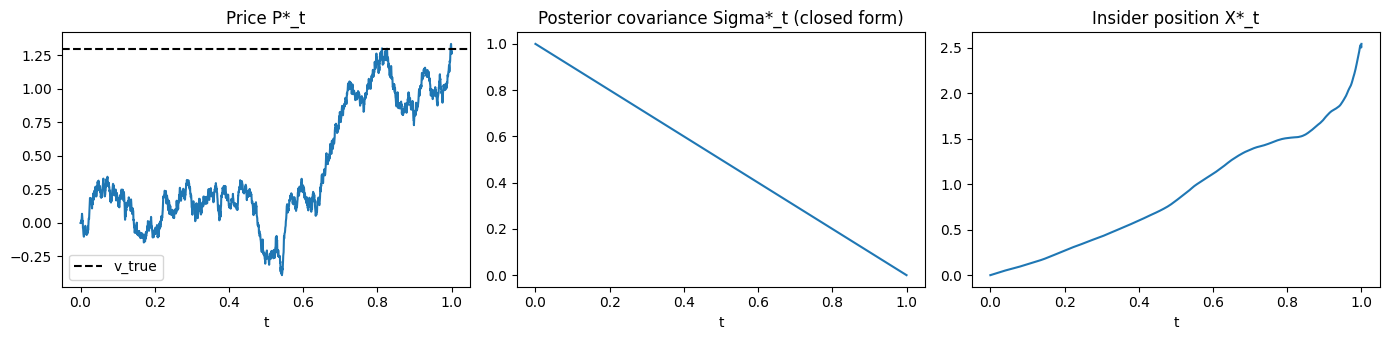

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(path["t"], path["P"][:, 0]); axes[0].axhline(v_true[0], color="k", ls="--", label="v_true")
axes[0].set_title("Price P*_t"); axes[0].legend()
axes[1].plot(path["t"], model.Sigma_star(path["t"]))
axes[1].set_title("Posterior covariance Sigma*_t (closed form)")
axes[2].plot(path["t"], path["X"][:, 0])
axes[2].set_title("Insider position X*_t")
for ax in axes: ax.set_xlabel("t")
plt.tight_layout(); plt.show()

## Component 3 — Matrix Doob-Meyer decomposition (Appendix B)

The paper's Theorem B.3 generalizes the classical Doob-Meyer decomposition to
(not-necessarily-symmetric) matrix-valued local submartingales: `X_t = M_t + A_t`.
Below is a small numeric illustration on a toy 2x2 submartingale with a KNOWN
conditional-mean map (needed since a single realized path alone cannot identify the
true compensator).

In [4]:
from kyle_liquidity.doob_meyer import MatrixDoobMeyer

rng = np.random.default_rng(0)
n_steps_dm = 200
X = np.zeros((n_steps_dm + 1, 2, 2))
X[0] = np.eye(2)
def cond_mean_fn(X_j, j):
    # A toy submartingale: E[X_{j+1}|F_j] = X_j + 0.01 * I (deterministic positive drift)
    return X_j + 0.01 * np.eye(2)
for j in range(n_steps_dm):
    X[j+1] = cond_mean_fn(X[j], j) + 0.05 * rng.normal(size=(2,2))

dm = MatrixDoobMeyer(cond_mean_fn=cond_mean_fn)
M, A = dm.decompose(X)
print("Reconstruction max abs error (X - (M+A)):", np.max(np.abs(X - (M + A))))
print("A is nondecreasing (Loewner order) along the path:",
      all(np.all(np.linalg.eigvalsh(A[k+1]-A[k]) >= -1e-9) for k in range(n_steps_dm)))

Reconstruction max abs error (X - (M+A)): 2.220446049250313e-16
A is nondecreasing (Loewner order) along the path: True


## Full verification suite (all Section 5 benchmark cases)

This mirrors `run_verification.py --case all` — runs Kyle (1985), Back-Pedersen
(1998), Collin-Dufresne-Fos (2016), and the common-eigenbasis/BCEL (2020) cases, and
checks each against its closed form.

In [ ]:
import numpy as np

# Fix for NumPy 1.26 compatibility
if not hasattr(np, "trapezoid"):
    np.trapezoid = np.trapz

from kyle_liquidity.utils.config import ExperimentConfig
from kyle_liquidity.verification import run_all

cfg = ExperimentConfig.from_yaml("../configs/config.yaml")
cfg.training["n_steps"] = 1000

results = run_all(cfg, case="all")

import json
print(json.dumps(results, indent=2))

{
  "kyle1985": {
    "case": "kyle1985",
    "terminal_covariance_identity_residual": 2.0000000000575113e-06,
    "terminal_price_error": 0.020993625523455295,
    "min_eig_M_along_path": 1.0,
    "inconspicuous": true
  },
  "back_pedersen1998": {
    "case": "back_pedersen1998",
    "terminal_covariance_identity_residual": 1.7777807077568042e-06,
    "terminal_price_error": 0.01970344251670131,
    "min_eig_M_along_path": 1.0606601717798212
  },
  "cdf2016": {
    "case": "collin_dufresne_fos2016",
    "terminal_covariance_identity_mc_mean": 0.9999999191670597,
    "terminal_covariance_identity_target": 1.0,
    "terminal_covariance_identity_mc_abs_error": 8.083294034122446e-08,
    "n_mc_paths": 50
  },
  "common_eigenbasis": {
    "case": "common_eigenbasis_bcel2020",
    "n_assets": 3,
    "eigen_vs_direct_abs_error_mean": 8.172475042379625e-17,
    "eigen_vs_direct_abs_error_max": 1.942890293094024e-16,
    "eigen_vs_direct_rel_error_mean": 7.927886119501845e-16,
    "eigen_vs_d

## Paper results comparison

This paper reports **no numerical results table** (`evaluation_protocol.reported_results`
is empty in the SIR) — its "evaluation" is entirely the analytical recovery of five known
closed-form equilibria (Kyle 1985, Back 1992, Back-Pedersen 1998, Collin-Dufresne-Fos
2016, Back-Cocquemas-Ekren-Lioui 2020) as special cases of the general variational
construction. The cell above *is* the results comparison for this paper: every
`terminal_covariance_identity_*` and `eigen_vs_direct_*` residual should be at or near
machine/quadrature precision, since these are exact identities, not statistical
estimates.

## What to do next

1. **Full verification run**: `python run_verification.py --config configs/config.yaml --case all`
2. **Grade against tolerance**: `python compare_to_paper.py --results outputs/verification_results.json`
3. **Single-path inspection**: `python inference.py --seed 0`

**Top implementation notes from the SIR** (`sir-registry/arxiv_2607_10934/sir.json`):
- Section 5.7's general matrix case is an *open problem in the paper itself* — implemented only as an unverified stub (confidence 0.3).
- MDC (Definition 3.1) has no general numerical certificate — only an empirical min-eigenvalue health check is provided (confidence ~0.4, see SIR `ambiguities`).
- No numerical BSDE solver is specified for Section 5.5's scalar stochastic-liquidity case — out of scope here, documented as future work.